# Attempt to read the damaged N280 RBR quartz rsk file with pimos

In [1]:
import pIMOS.xrwrap.rbr_duet as rbr
import os
import matplotlib.pyplot as plt
import datetime
import numpy as np 



INITIALISING pIMOS


In [2]:
#filename='../../../SWOT_Cruise/RBRqu/N280_213896_20230629_1353.rsk'
filename='../../../SWOT_Cruise/RBRqu/213896_20230818_1714_rebuilt.rsk'

rr, ds = rbr.from_rsk_quartz(filename)
ds

Opening file....
Reading file....
Done reading.
Calculating bottom pressure
Done.
Really slow loops here to get data - switch to better SQL commands at some point.....
.....done
Initialising accessor.
STORING RAW FILE ATTRIBUTES
Setting attribute "title" to "Measured data from an RBR Data Logger"
Setting attribute "source" to "RBR Data Logger"
Setting attribute "process_level" to "1"
Measured data from an RBR Data Logger
Measured data from an RBR Data Logger
RBR Data Logger
RBR Data Logger
1
1
WARNING, COMPLIANCE CHECK NOT YET IMPLEMENTED.
WARNING, COMPLIANCE CHECK NOT YET IMPLEMENTED.


<xarray.Dataset> Size: 809MB
Dimensions:          (time: 25295878)
Coordinates:
  * time             (time) datetime64[ms] 202MB 2023-03-13T04:12:56 ... 2023...
Data variables:
    BPR_Pressure     (time) float64 202MB 3.559e+06 3.559e+06 ... 1.814e+06
    Temperature      (time) float64 202MB 31.61 31.61 31.61 ... 31.6 31.6 31.6
    BPR_Temperature  (time) float64 202MB -5.153e+04 -5.153e+04 ... -4.575e+04
Attributes: (12/34)
    title:                           Measured data from an RBR Data Logger
    institution:                     The University of Western Australia
    institution_division:            Ocean Dynamics
    source:                          
    project:                         
    history:                         
    ...                              ...
    pressure_sensor_height_asb:      
    nominal_instrument_height_asb:   
    nominal_instrument_orientation:  
    timezone:                        
    process_level:                   Process Level 0
    is_profile_data:                 0

In [12]:
outfilename='../../../SWOT_Cruise/RBRqu/N280_RBRQu_213896_20230818_1714_rebuilt.nc'
ds.to_netcdf(outfilename)

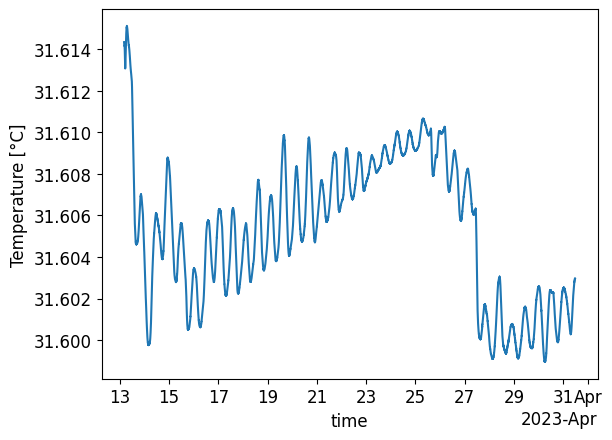

In [11]:
ds['Temperature'].isel(time=slice(None,None,60)).plot()

In [7]:
from pyrsktools import RSK

rsk = RSK(filename)
#rsk.open()
print(rsk)

RSK
  Internal state attributes:
    .filename is populated
    .logs is unpopulated
    .version is populated
  Informational attributes:
    .appSettings is unpopulated
    .calibrations is unpopulated
    .channels is unpopulated
    .dbInfo is unpopulated
    .deployment is unpopulated
    .diagnosticsChannels is unpopulated
    .diagnosticsData is unpopulated
    .epoch is unpopulated
    .geoData is unpopulated
    .instrument is unpopulated
    .instrumentChannels is unpopulated
    .instrumentSensors is unpopulated
    .parameterKeys is unpopulated
    .parameters is unpopulated
    .power is unpopulated
    .ranging is unpopulated
    .regions is unpopulated
    .schedule is unpopulated
    .scheduleInfo is unpopulated
  Computational attributes:
    .data is unpopulated
    .processedData is unpopulated



In [9]:
rsk.open()
rsk.readdata(None, None)

longNames = [c.longName for c in rsk.channels]
longNames




['temperature', 'period', 'period1']

In [10]:
rsk.deriveBPR()
longNames = [c.longName for c in rsk.channels]
longNames

['temperature', 'period', 'period1', 'bpr_pressure', 'bpr_temperature']

# See 
https://docs.rbr-global.com/sup/pressure-temperature-correction-of-pressure